# For the BrainHack course project - fMRI connectivity matrix mapping

In [1]:
#The sleepy group

In [3]:
!pip install nilearn

In [5]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from nilearn import image, plotting
from nilearn.maskers import NiftiMapsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn import datasets

In [7]:
from pathlib import Path
# Set this to path of where dataset is stored
dataset_root = Path("/Users/Gaithtry/Downloads/brain_hack/fmri_eeg_sleep/sub-01")

func_file = dataset_root / "sub-01_task-rest_run-1_processed.nii.gz"

print("Using:", func_file)

Using: /Users/Gaithtry/Downloads/brain_hack/fmri_eeg_sleep/sub-01/sub-01_task-rest_run-1_processed.nii.gz


In [10]:
atlas_dataset = datasets.fetch_atlas_msdl()
atlas_maps = image.load_img(atlas_dataset.maps)
atlas_labels = atlas_dataset.labels

atlas_masker = NiftiMapsMasker(
    maps_img=atlas_maps,
    standardize=True,
    detrend=True,
    memory="nilearn_cache",
    memory_level=1
)

atlas_masker.fit()

[fetch_atlas_msdl] Dataset found in /Users/Gaithtry/nilearn_data/msdl_atlas

NiftiMapsMasker(detrend=True,
                maps_img=<nibabel.nifti1.Nifti1Image object at 0x146ef52b0>,
                memory='nilearn_cache', memory_level=1, standardize=True)

In [12]:
correlation_measure = ConnectivityMeasure(kind="correlation")

def compute_connectivity(func_file):
    fmri_img = image.load_img(func_file)
    timeseries = atlas_masker.transform(fmri_img)
    matrix = correlation_measure.fit_transform([timeseries])[0]
    
    return timeseries, matrix

In [14]:
def plot_connectivity_matrix(matrix, labels, title="Connectivity Matrix"):
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(matrix, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=90, fontsize=7)
    ax.set_yticklabels(labels, fontsize=7)
    plt.colorbar(im, ax=ax, label="Pearson r")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [16]:
timeseries, matrix = compute_connectivity(func_file)

/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: UserWarning: Resampling maps at transform time...
To avoid this warning, make sure to pass the images you want to transform to fit() first, or directly use fit_transform().
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscor

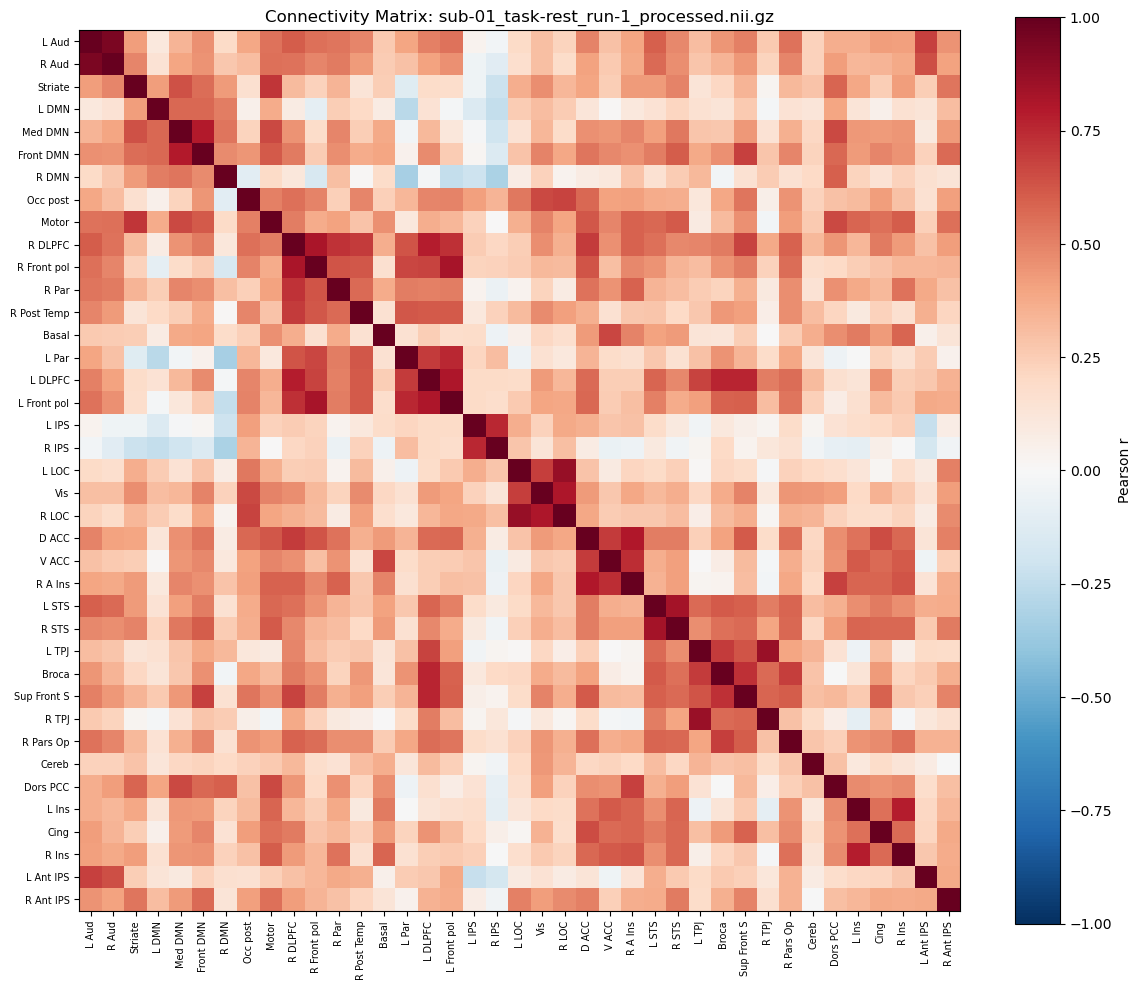

In [18]:
plot_connectivity_matrix(
    matrix,
    atlas_labels,
    title=f"Connectivity Matrix: {func_file.name}"
)

Processing: Sub-04_task-sleep_run-6_processed.nii.gz


/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: UserWarning: Resampling maps at transform time...
To avoid this warning, make sure to pass the images you want to transform to fit() first, or directly use fit_transform().
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscor

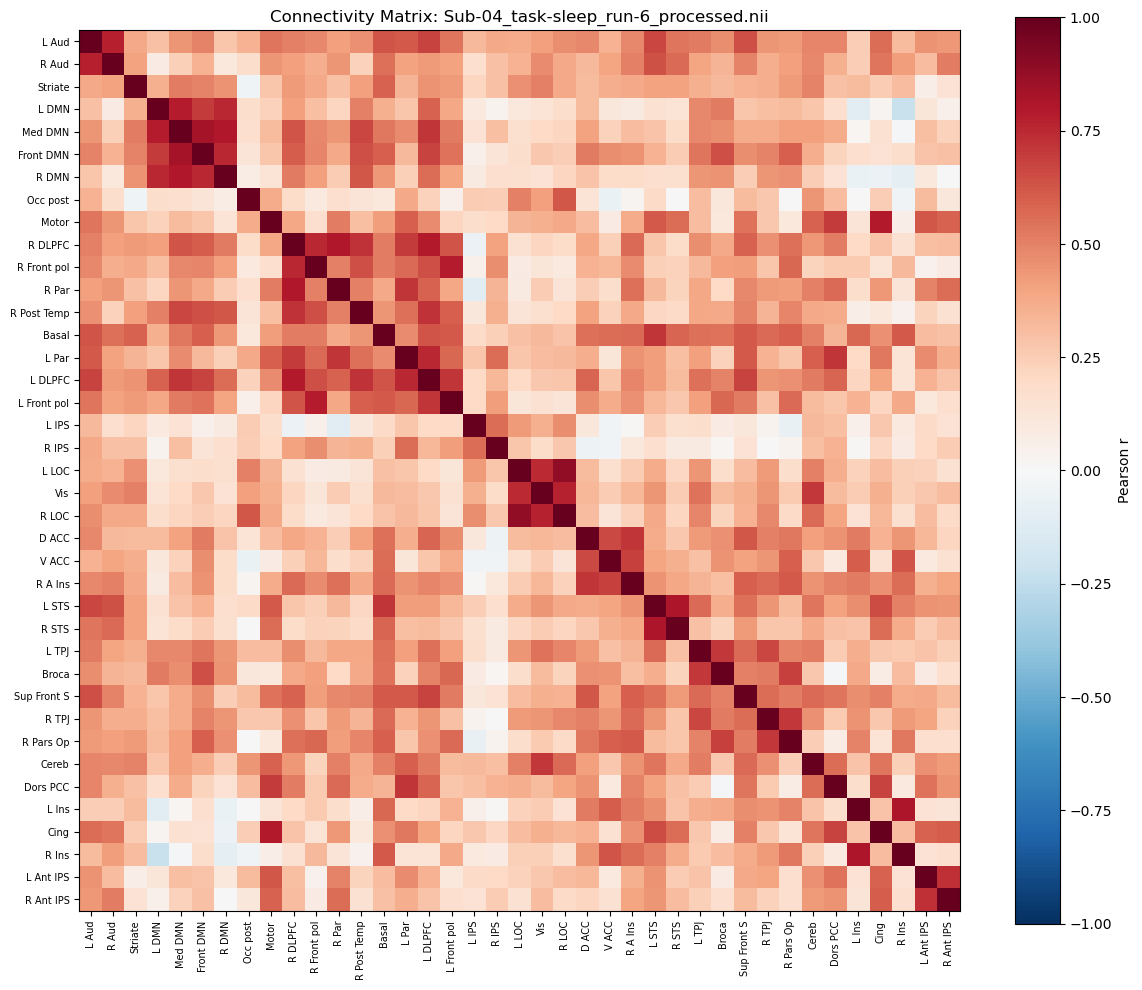

Processing: Sub-04_task-sleep_run-7_processed.nii.gz


/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: UserWarning: Resampling maps at transform time...
To avoid this warning, make sure to pass the images you want to transform to fit() first, or directly use fit_transform().
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscor

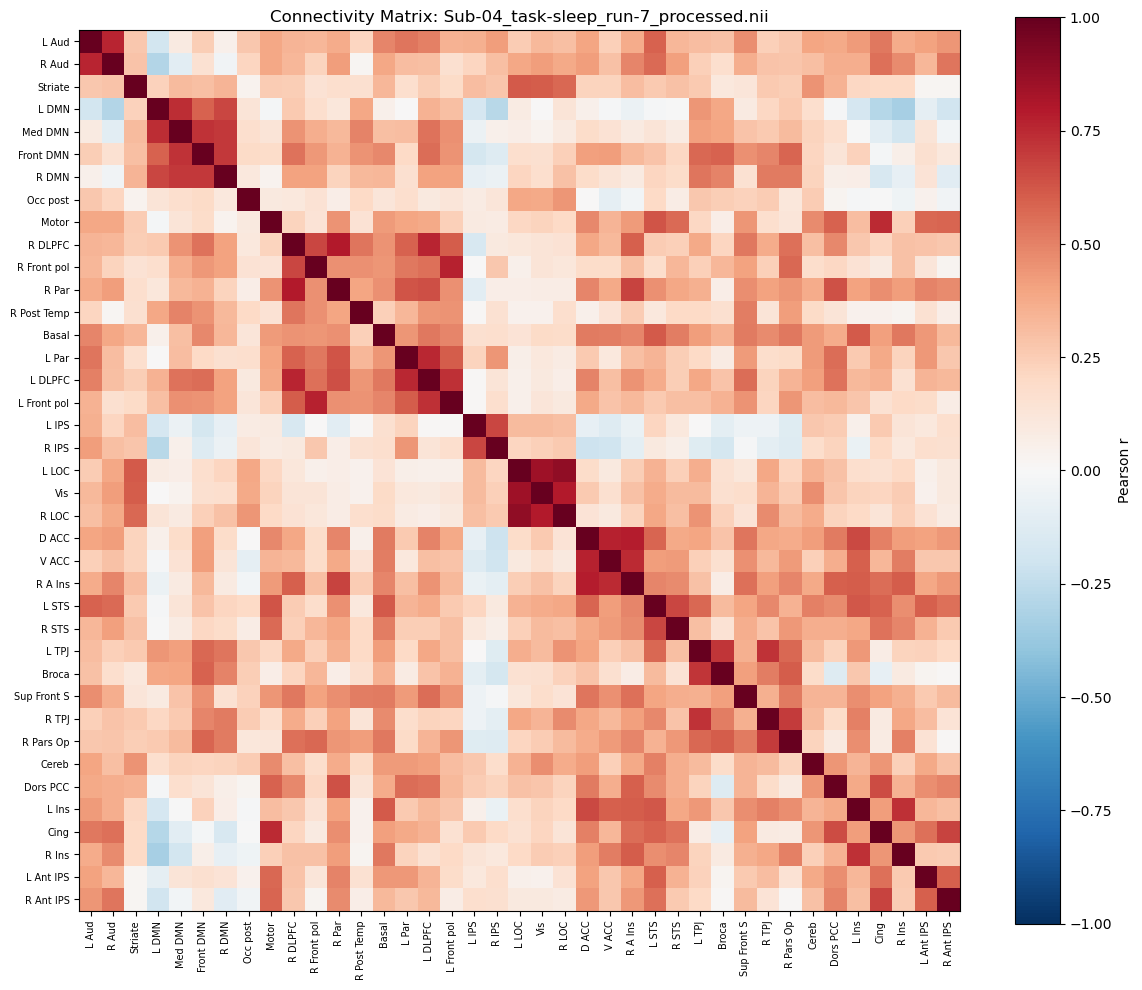

Processing: sub-04_task-rest_run-1_processed.nii.gz


/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: UserWarning: Resampling maps at transform time...
To avoid this warning, make sure to pass the images you want to transform to fit() first, or directly use fit_transform().
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscor

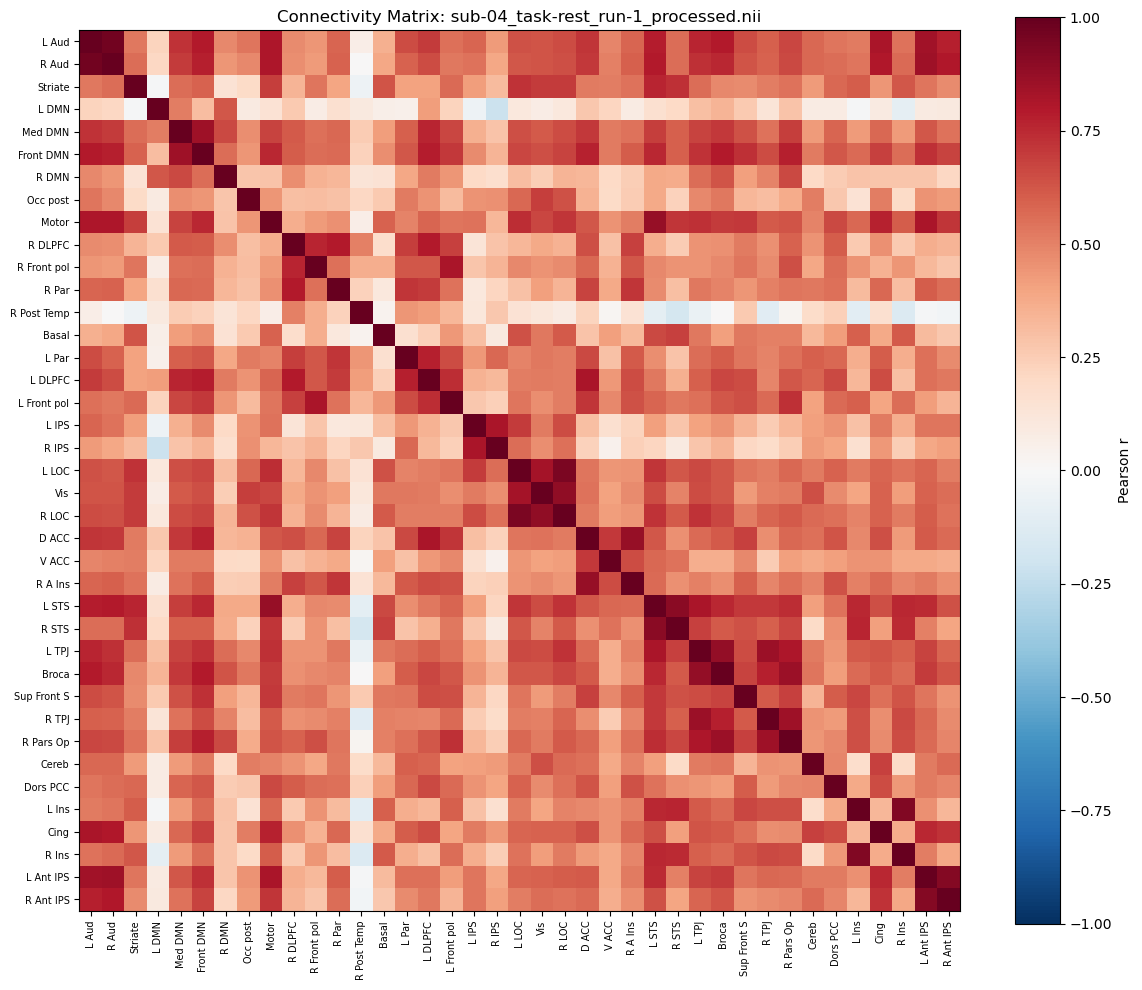

Processing: sub-04_task-rest_run-2_processed.nii.gz


/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: UserWarning: Resampling maps at transform time...
To avoid this warning, make sure to pass the images you want to transform to fit() first, or directly use fit_transform().
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscor

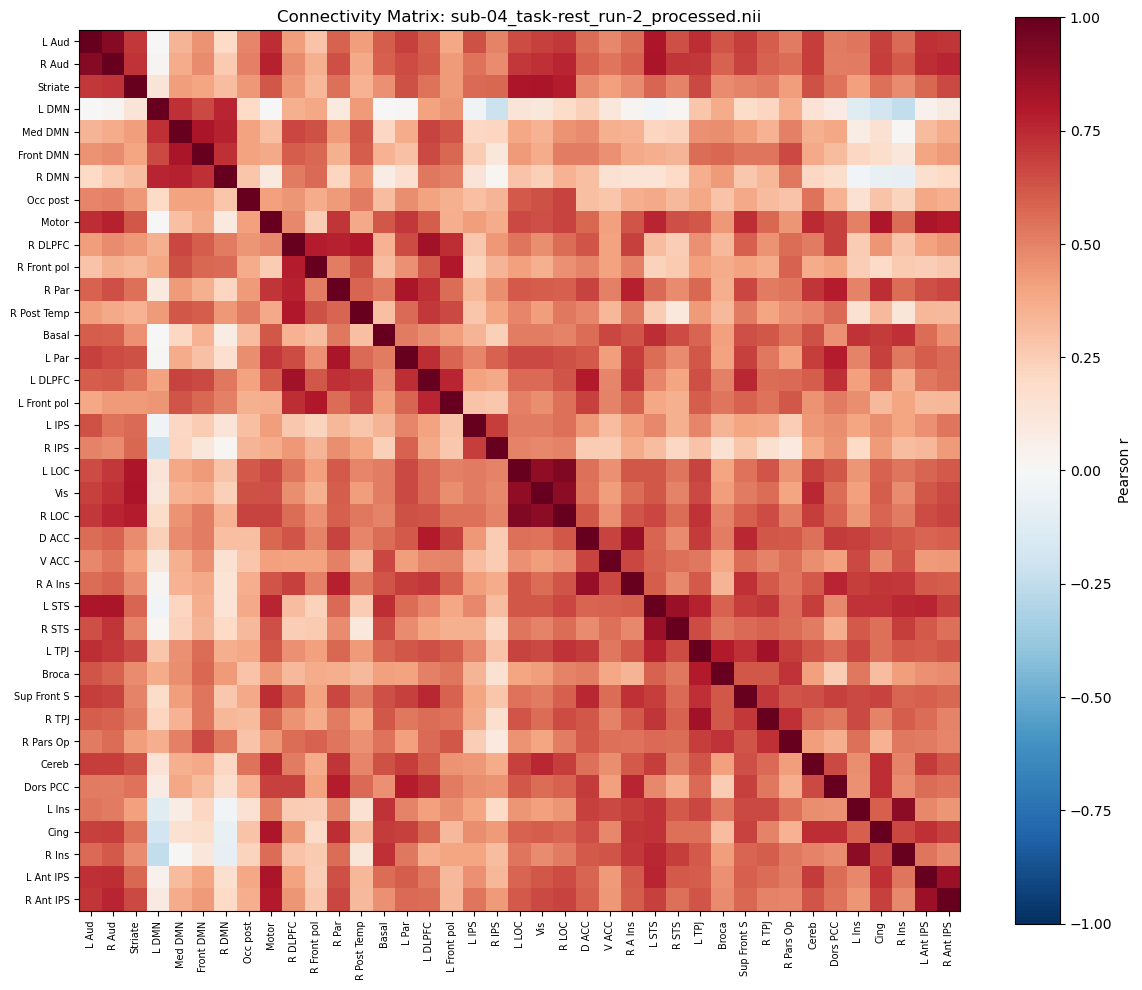

Processing: sub-04_task-sleep_run-1_processed.nii.gz


/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: UserWarning: Resampling maps at transform time...
To avoid this warning, make sure to pass the images you want to transform to fit() first, or directly use fit_transform().
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscor

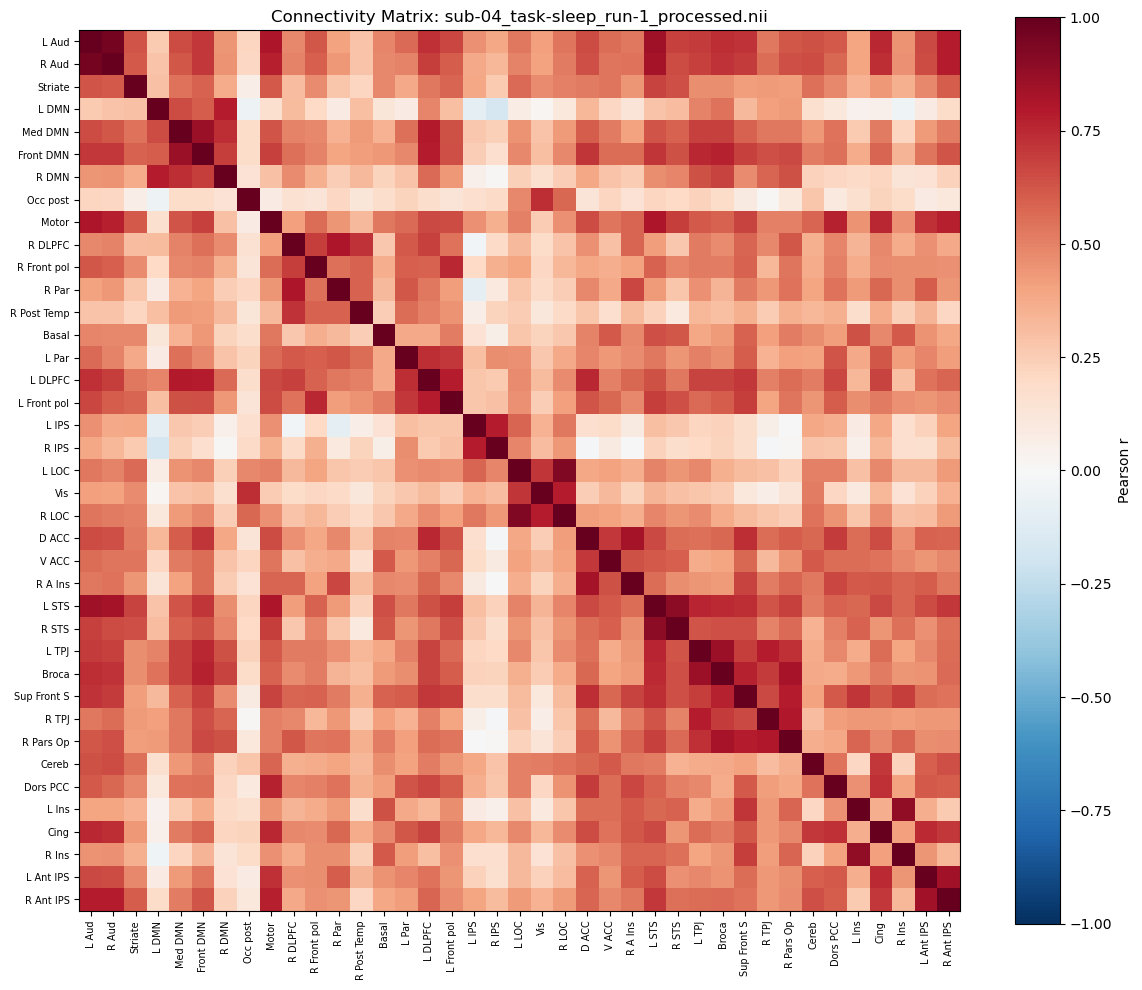

Processing: sub-04_task-sleep_run-2_processed.nii.gz


/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: UserWarning: Resampling maps at transform time...
To avoid this warning, make sure to pass the images you want to transform to fit() first, or directly use fit_transform().
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscor

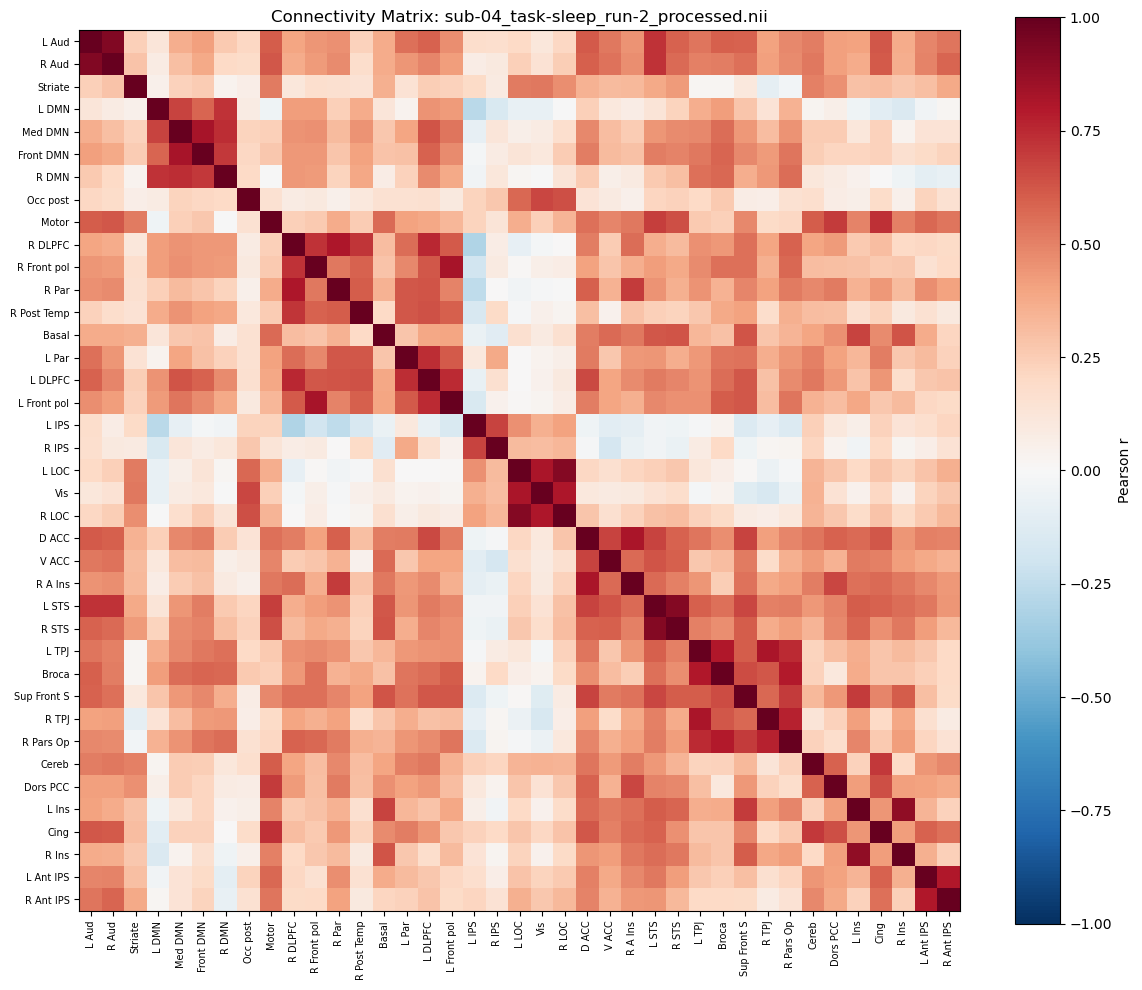

Processing: sub-04_task-sleep_run-3_processed.nii.gz


/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: UserWarning: Resampling maps at transform time...
To avoid this warning, make sure to pass the images you want to transform to fit() first, or directly use fit_transform().
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscor

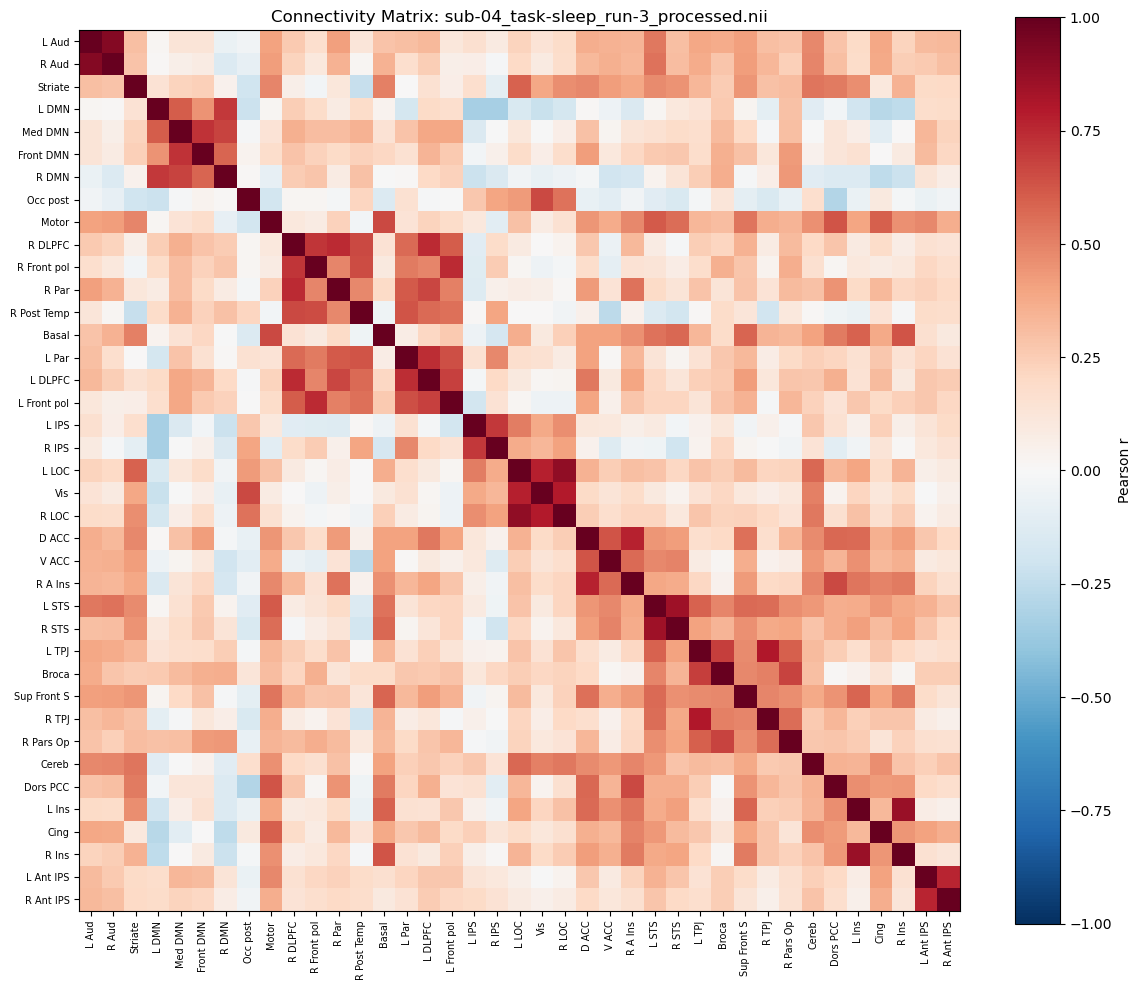

Processing: sub-04_task-sleep_run-4_processed.nii.gz


/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: UserWarning: Resampling maps at transform time...
To avoid this warning, make sure to pass the images you want to transform to fit() first, or directly use fit_transform().
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscor

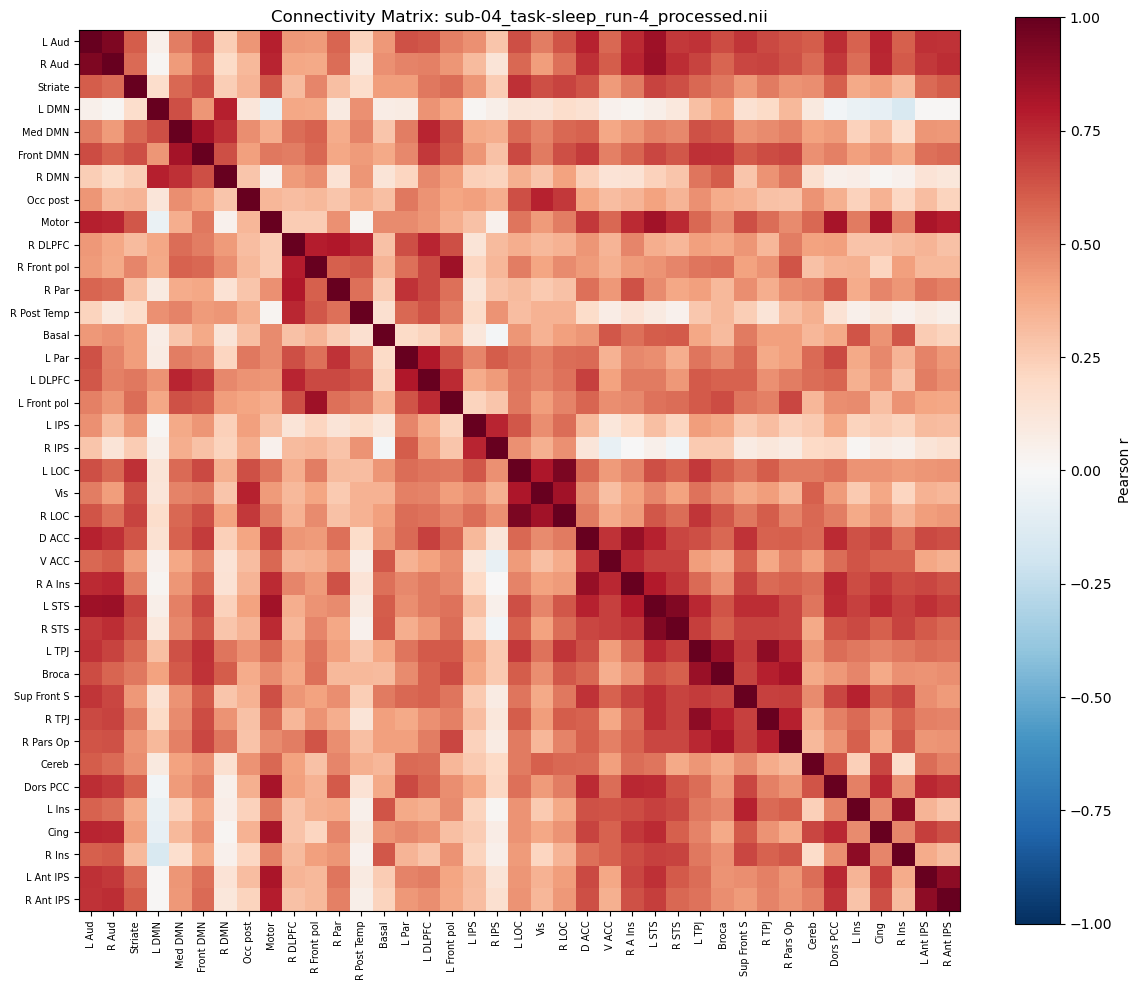

Processing: sub-04_task-sleep_run-5_processed.nii.gz


/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: FutureWarning: The 'zscore' strategy incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.14.0, the 'zscore' option will be removed and using standardize=True will fall back to 'zscore_sample'.To avoid this warning, please use 'zscore_sample' instead.
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:5: UserWarning: Resampling maps at transform time...
To avoid this warning, make sure to pass the images you want to transform to fit() first, or directly use fit_transform().
  timeseries = atlas_masker.transform(fmri_img)
/var/folders/fs/j7mzyn0108nf8c8x6ny97trc0000gq/T/ipykernel_2341/341335372.py:6: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscor

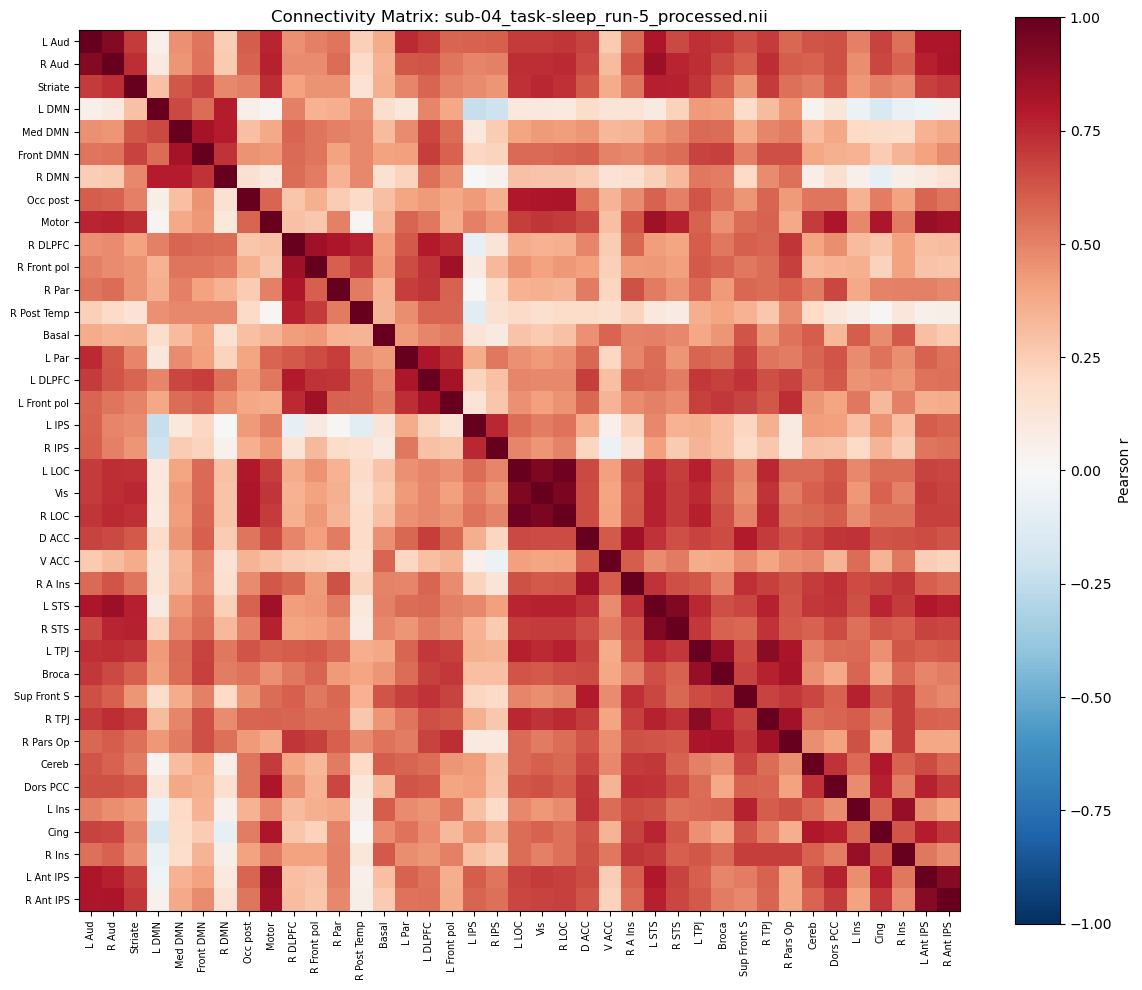

In [22]:
#for running through the multiple cases:

from pathlib import Path

dataset_root = Path("/Users/Gaithtry/Downloads/brain_hack/fmri_eeg_sleep/sub-04")

func_files = sorted(dataset_root.glob("*.nii.gz"))

for func_file in func_files:
    print("Processing:", func_file.name)

    timeseries, matrix = compute_connectivity(func_file)

    plot_connectivity_matrix(
    matrix,
    atlas_labels,
    title=f"Connectivity Matrix: {func_file.stem}"
)